In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def get_binning_test_data(start,stop,step,file_name):
    _grad_data = []
    for i in range(2):
        for j in range(start,stop,step):
            print(f'Loading worker {1} epoch {i} batch {j}')
            with np.load(f'../gradients/worker_{1}/grads_epoch_{i}_batch_{j}.npz') as data:
                g = [data[key].astype(np.float16).flatten()
                     for key in data.files[::2][:]]
                [gg.sort() for gg in g]
                _grad_data.append(g)
    _grad_data=[np.sort(np.concatenate(gg)) for gg in zip(*_grad_data)]
    all_grads=np.concatenate(_grad_data)
    np.savez_compressed(f'../gradients/wz binning test/{file_name}', all_grads=all_grads)

# get_binning_test_data(0, 40, 4, 'train_x.npz')
# get_binning_test_data(1, 40, 4, 'test_x.npz')
# get_binning_test_data(2, 40, 4, 'train_y.npz')
# get_binning_test_data(3, 40, 4, 'test_y.npz')

train_x = np.load('exp_data/gradients/wz binning test/train_x.npz')['all_grads']
test_x = np.load('exp_data/gradients/wz binning test/test_x.npz')['all_grads']
train_y = np.load('exp_data/gradients/wz binning test/train_y.npz')['all_grads']
test_y = np.load('exp_data/gradients/wz binning test/test_y.npz')['all_grads']

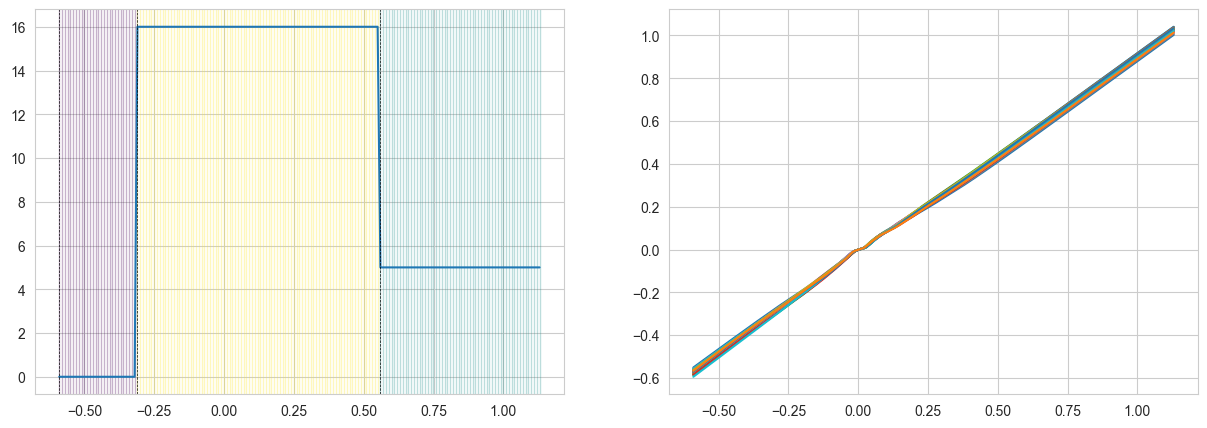

tau=0.7171
Epoch 26: train loss=3.819083, train_distortion=-45.413200 dB, eval_distortion=-49.154677 dB
train_distortion=0.000029, eval_distortion=0.000012
rate: 4.952185 bits
tau=0.7079
Epoch 27: train loss=3.829439, train_distortion=-46.154182 dB, eval_distortion=-53.471563 dB
train_distortion=0.000024, eval_distortion=0.000004
rate: 4.945483 bits


KeyboardInterrupt: 

In [56]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Brent_code.config import parse_args
from Brent_code.model import EncoderDecoder
from IPython.display import clear_output

args=parse_args(layered=False)
args.debug = True
args.code_size=2**5
args.log_name = 'res/wz binning test'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Creating model
model = EncoderDecoder(input_dim=args.sample_dim, layers=args.layers, hidden_dim=args.hidden_units,
                       code_size=args.code_size, marginal=args.marginal)
model = model.to(device).to(torch.float)

optimizer = torch.optim.Adam(lr=args.lr, params=model.parameters())
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args.lr_step, gamma=0.3)
mse_loss = nn.MSELoss()

TRAIN_BATCHES = int(args.samples_per_epoch // args.batch_size)

for epoch in range(args.epochs):

    # Train
    model.train()

    train_loss = 0.0
    train_mse_loss = 0.0

    tau_t = args.tau * np.exp(epoch/args.epochs * np.log(0.1 / args.tau))
    print('tau={:.04f}'.format(tau_t))

    x_data = torch.from_numpy(train_x).reshape(-1,1).to(torch.float)
    y_data = torch.from_numpy(train_y).reshape(-1,1).to(torch.float)
    for batch_idx in range(TRAIN_BATCHES):

        optimizer.zero_grad()

        # Source model:
        #   X = Y+N,    Y~N(0, Y_STD),  N~N(0, NOISE_STD)
        # asdasdYYYY torch.empty([args.batch_size, args.sample_dim], device=device).normal_(mean=0, std=args.y_std)
        # asdasdXXXX y + torch.empty_like(y).normal_(mean=0, std=np.sqrt(args.noise_power))
        x = x_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)
        y = y_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)

        reconstruct, bin, out, prior = model.forward(x, y, tau=tau_t)

        p_ux = out[torch.arange(out.size(0)), bin]
        p_u = prior[torch.arange(out.size(0)), bin] # it is also p_u|y for the conditional model

        dist = mse_loss(reconstruct, x)
        loss = torch.mean(torch.log(p_ux/(p_u + 1e-12))) + args.ld * dist

        train_loss += loss.item()
        train_mse_loss += dist.item()

        loss.backward()

        optimizer.step()

    scheduler.step()

    train_db = 10 * np.log10(train_mse_loss / TRAIN_BATCHES)
    train_mse_loss = train_mse_loss / TRAIN_BATCHES
    train_loss = train_loss / TRAIN_BATCHES

    # Eval:

    eval_mse_loss = 0.0
    eval_rate = 0.0

    test_samples = args.samples_per_epoch
    if epoch == args.epochs - 1 or (args.debug is False and epoch % 5 == 0):
        test_samples = args.test_samples
    test_batches = int(test_samples // args.batch_size)

    model.eval()
    x_data = torch.from_numpy(test_x).reshape(-1,1).to(torch.float)
    y_data = torch.from_numpy(test_y).reshape(-1,1).to(torch.float)
    with torch.no_grad():
        for batch_idx in range(test_batches):
            # Source model:
            #   X = Y+N,    Y~N(0, Y_STD),  N~N(0, NOISE_STD)
            # asdasdYYYY torch.empty([args.batch_size, args.sample_dim], device=device).normal_(mean=0, std=args.y_std)
            # asdasdXXXX y + torch.empty_like(y).normal_(mean=0, std=np.sqrt(args.noise_power))
            x = x_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)
            y = y_data[batch_idx*args.batch_size:(batch_idx+1)*args.batch_size].to(device)

            reconstruct, bin, code_probs, prior = model.forward(x, y)

            p_u = prior[torch.arange(code_probs.size(0)), bin] # also the conditional one for the second model

            dist = mse_loss(reconstruct, x)

            eval_mse_loss += dist.item()

            eval_rate += torch.mean(-torch.log2(p_u + 1e-12)).item()

    eval_db = 10*np.log10(eval_mse_loss / test_batches)
    eval_rate = eval_rate / test_batches
    print('Epoch {}: train loss={:.06f}, train_distortion={:.06f} dB, eval_distortion={:.06f} dB'
          .format(epoch, train_loss, train_db, eval_db))
    print('train_distortion={:.06f}, eval_distortion={:.06f}'
          .format(train_mse_loss, eval_mse_loss / test_batches))
    print('rate: {:.06f} bits'.format(eval_rate))

    os.makedirs(args.log_name, exist_ok=True)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'lambda': args.ld,
        'config': args,
    }, os.path.join(args.log_name, 'checkpoint.pth'))
    
    
    min_v, max_v = test_x.min()*1.01, test_x.max()*1.01
    model.eval()
    with torch.no_grad():
        # 1D source:
        # Seeing if there is binning:
        if (args.debug and epoch % 5 == 0) or (args.debug is False and epoch == args.epochs-1):
            # clear notebook output
            clear_output()

            fig, ax = plt.subplots(nrows=1, ncols=2)
            fig.set_size_inches(15, 5)
            
            x= torch.arange(min_v, max_v, 0.01).to(device).unsqueeze(1)
            y= torch.zeros_like(x)
            with torch.no_grad():
                reconstruct, bin, _, _ = model.forward(x, y)
            
            ax[0].plot(x.detach().cpu().numpy(), bin.detach().cpu().numpy())
            
            bin = bin.detach().cpu().numpy()
            x = x.detach().cpu().numpy()
            unique_v = np.unique(bin)
            colors = plt.cm.viridis(np.linspace(0, 1, len(unique_v)))
            for i, val in enumerate(unique_v):
                mask = bin == val
                ax[0].axvline(x[mask][0], color='black', linestyle='--', linewidth=0.5)
                temp = [x[mask][0][0], x[mask][0][0]]
                for j in range(1, len(x[mask])):
                    if temp[1] + 0.005 < x[mask][j][0]:  # Adjusted threshold to 0.005
                        ax[0].axvspan(*temp, color=colors[i], alpha=0.3)
                        temp[0] = x[mask][j][0]
                    temp[1] = x[mask][j][0]
                ax[0].axvspan(*temp, color=colors[i], alpha=0.3)  # Ensure the last span is added
            
            # Seeing the reconstruction points
            for i in range(args.code_size):
                y= torch.arange(min_v, max_v, 0.01).to(device).unsqueeze(1)
                codes = F.one_hot(torch.ones([y.shape[0]], dtype=torch.long, device=device)*i,
                                  num_classes=args.code_size).float()
                reconstruct = model.decoder(codes, y)
            
                ax[1].plot(y.detach().cpu().numpy(), reconstruct.detach().cpu().numpy(), label='bin={}'.format(i))
            plt.show()

        if epoch == args.epochs - 1 or (args.debug is False and epoch % 5 == 0):
            with open(os.path.join(args.log_name, 'results.txt'), 'a') as myfile:
                myfile.write('Epoch={}\n'.format(epoch))
                myfile.write('train_distortion={:.08f}, eval_distortion={:.08f}, rate: {:.06f} bits\n'
                             .format(train_mse_loss / TRAIN_BATCHES,
                                     eval_mse_loss / test_batches, eval_rate))


